In [1]:
import torch
from transformers import GPT2Model, GPT2Tokenizer
import matplotlib.pyplot as plt

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2")
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5404.09it/s]

Ready!


In [2]:
from torch.nn.functional import cosine_similarity

text = "The quick brown fox jumps over the lazy dog near the river bank"

# Tokenize aur embeddings nikalo
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = model(**inputs)

embeddings = outputs.last_hidden_state[0]  # [n_tokens, 768]

# Consecutive tokens ki similarity
seq_similarities = []
for i in range(len(tokens) - 1):
    sim = cosine_similarity(
        embeddings[i].unsqueeze(0),
        embeddings[i+1].unsqueeze(0)
    ).item()
    seq_similarities.append(sim)

print("Tokens:", tokens)
print("\nSequential Similarities:")
for i, sim in enumerate(seq_similarities):
    print(f"  {tokens[i]:10} → {tokens[i+1]:10} : {sim:.4f}")

Tokens: ['The', 'Ġquick', 'Ġbrown', 'Ġfox', 'Ġjumps', 'Ġover', 'Ġthe', 'Ġlazy', 'Ġdog', 'Ġnear', 'Ġthe', 'Ġriver', 'Ġbank']

Sequential Similarities:
  The        → Ġquick     : 0.9664
  Ġquick     → Ġbrown     : 0.9923
  Ġbrown     → Ġfox       : 0.9955
  Ġfox       → Ġjumps     : 0.9696
  Ġjumps     → Ġover      : 0.9922
  Ġover      → Ġthe       : 0.9924
  Ġthe       → Ġlazy      : 0.9935
  Ġlazy      → Ġdog       : 0.9869
  Ġdog       → Ġnear      : 0.9779
  Ġnear      → Ġthe       : 0.9762
  Ġthe       → Ġriver     : 0.9711
  Ġriver     → Ġbank      : 0.9942


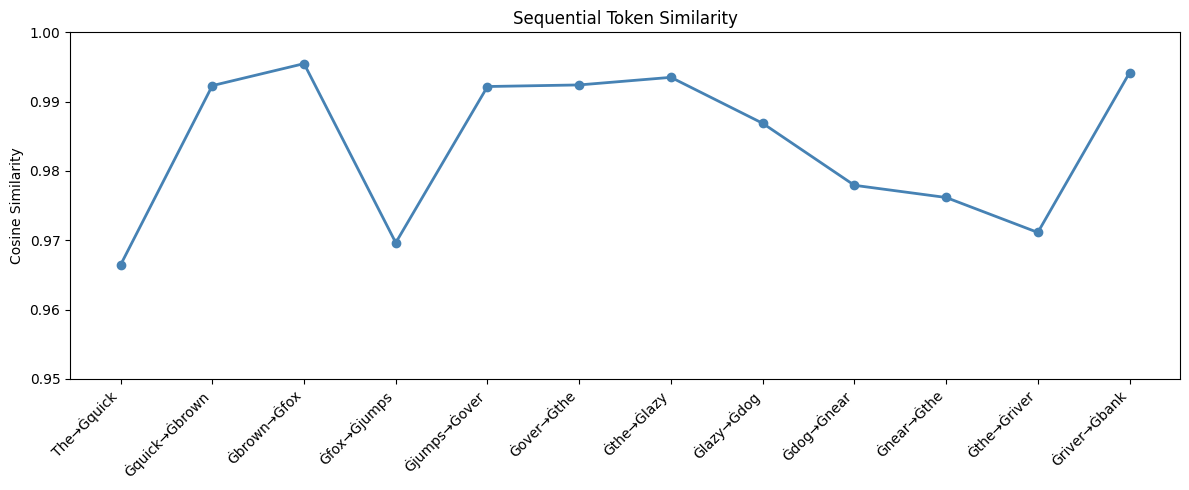

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(seq_similarities))
ax.plot(x, seq_similarities, marker='o', color="steelblue", linewidth=2)

# X axis pe token pairs
pair_labels = [f"{tokens[i]}→{tokens[i+1]}" for i in range(len(seq_similarities))]
ax.set_xticks(x)
ax.set_xticklabels(pair_labels, rotation=45, ha="right")

ax.set_ylabel("Cosine Similarity")
ax.set_title("Sequential Token Similarity")
ax.set_ylim(0.95, 1.0)

plt.tight_layout()
plt.show()



* **Consecutive tokens** usually have very high similarity, typically in the range of **0.96–0.99**.

* **Adjective + noun pairs** (e.g., *brown → fox*) tend to be **highly similar**, since they are closely related in meaning and context.

* At the **start of a sentence**, similarity is often lower because the **context has not been established yet**.

* **Common phrases** (e.g., *river → bank*) show **high similarity**, as they frequently occur together and form meaningful associations.
